# Radial integration of GIWAXS frames

Turn raw detector images into 1D intensity vs *q* (full-azimuthal radial integration) for downstream peak fitting and phase identification.

This notebook covers:

1. Integrating a single frame and plotting I(q).
2. Batch-integrating an _in situ_ stack of frames.
3. Plotting the _in situ_ heatmap (q vs frame index).
4. Saving the batch result as a CSV that [`06_peak_fitting_scherrer.ipynb`](06_peak_fitting_scherrer.ipynb) consumes.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from giwaxs_analysis import calibration, io, integration

## 1. Load the calibration

Same as [`01_check_calibration.ipynb`](01_check_calibration.ipynb) — point at your PONI + mask and pack them into a `Calibration` object.

In [12]:
PONI_PATH = '../data/calibrant_AgBh.poni'
MASK_PATH = '../data/mask.edf'

calib = calibration.load_calibration(PONI_PATH, MASK_PATH)
print(calibration.summarise(calib))

Pilatus2M  dist=275.7 mm  beam=(209.9, 35.8) mm  λ=1.2398 Å  E=10.000 keV  masked=8.0%


## 2. Azimuthally integrate a single frame

Pick one frame from the _in situ_ series, integrate over χ at each q, and plot I(q). Log y-axis so weaker peaks are visible alongside the bright primary reflections.

Two knobs:

- **`CHI_RANGE`** — azimuthal wedge in degrees (between –180 and 180). `None` = full circle. Convention (depends on detector orientation):
  - around `chi ≈ ±90°` — out-of-plane direction (e.g. `(-100, -80)`).
  - around `chi ≈ 0°` or `180°` — in-plane direction (e.g. `(-10, 10)`).
- **`Q_RANGE`** — restrict the radial range to a region of interest in Å⁻¹. `None` = whatever range the geometry covers.

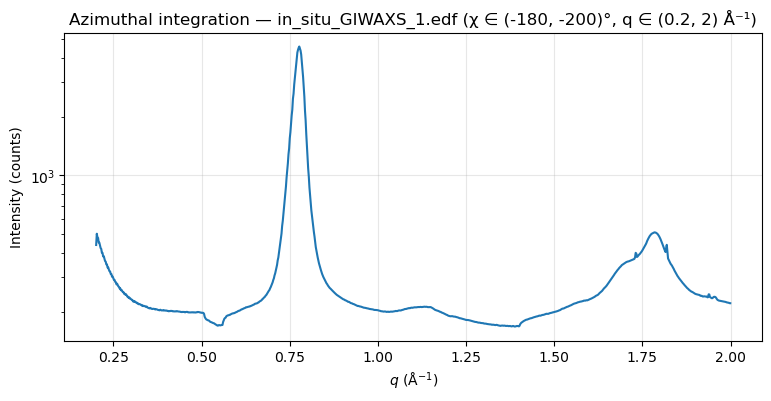

In [13]:
FRAME_PATH = '../data/insitu/in_situ_GIWAXS_1.edf'

# Both ranges default to None — set them to a tuple to restrict.
CHI_RANGE = -180, -200       # e.g. (-100, -80) for out-of-plane
Q_RANGE = 0.2, 2         # e.g. (0.2, 2.0)  for a peak of interest

frame = io.load_frame(FRAME_PATH)
q, I = integration.azimuthal_integrate(frame, calib, chi_range=CHI_RANGE, q_range=Q_RANGE)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(q, I)
ax.set_xlabel(r'$q$ (Å$^{-1}$)')
ax.set_ylabel('Intensity (counts)')
ax.set_yscale('log')
ax.set_title(
    f'Azimuthal integration — {FRAME_PATH.rsplit("/", 1)[-1]}'
    f' (χ ∈ {CHI_RANGE}°, q ∈ {Q_RANGE} Å⁻¹)'
)
ax.grid(True, alpha=0.3)
plt.show()

## 3. Batch-integrate the _in situ_ stack

`io.list_frames` + `io.load_stack` gather every frame in `data/insitu/` into a single 3D array; `batch_integrate` does the integration loop for you. Output is shaped `(N_frames, N_q_bins)`.

In [18]:
INSITU_DIR = '../data/insitu/'

paths = io.list_frames(INSITU_DIR)
print(f'Found {len(paths)} frames')

stack = io.load_stack(paths)
print(f'Stack shape: {stack.shape}')

q, I_2d = integration.batch_integrate(stack, calib)
print(f'q shape: {q.shape}, I_2d shape: {I_2d.shape}')

Found 5 frames
Stack shape: (5, 1679, 1475)
q shape: (1000,), I_2d shape: (5, 1000)


## 4. Overlay every integration with a colour gradient

The same data as the heatmap but as overlaid line plots, with each frame coloured from light blue (first in the series) to dark blue (last). Useful for spotting peak shifts / sharpening / new peaks emerging.

For larger series (~20+ frames) the lines start to overlap badly — the heatmap below is the better view there.

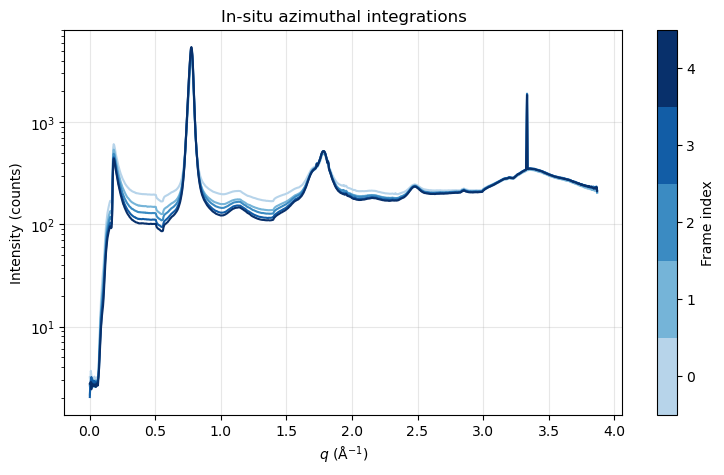

In [19]:
from matplotlib.colors import ListedColormap

n = len(I_2d)
cmap = plt.get_cmap('Blues')
# Skip the very light end (0.0–0.3) since pale colours vanish on a white background.
colors = cmap(np.linspace(0.3, 1.0, n))

fig, ax = plt.subplots(figsize=(9, 5))
for intensities, color in zip(I_2d, colors):
    ax.plot(q, intensities, color=color)

ax.set_xlabel(r'$q$ (Å$^{-1}$)')
ax.set_ylabel('Intensity (counts)')
ax.set_yscale('log')
ax.set_title('In-situ azimuthal integrations')
ax.grid(True, alpha=0.3)

# Discrete colourbar matching the line colours exactly.
sm = plt.cm.ScalarMappable(
    cmap=ListedColormap(colors),
    norm=plt.Normalize(vmin=-0.5, vmax=n - 0.5),
)
plt.colorbar(sm, ax=ax, ticks=range(n), label='Frame index')

plt.show()

## 5. _In situ_ heatmap

A quick look at the _in situ_ series. For a thickness scan, you'd expect peak *positions* to stay constant while intensities scale roughly with film thickness. For a temperature or anneal scan, you'd expect peaks to shift / sharpen / split.

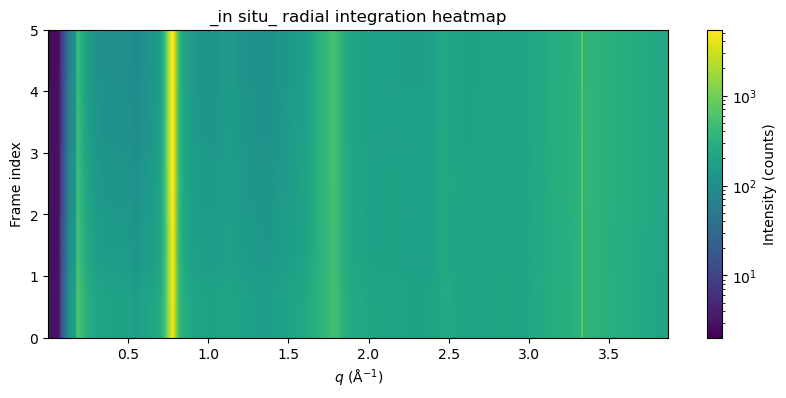

In [15]:
# Clip non-positive values for LogNorm.
I_plot = np.where(I_2d > 0, I_2d, np.nan)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(
    I_plot,
    aspect='auto',
    origin='lower',
    extent=(q.min(), q.max(), 0, len(I_2d)),
    cmap='viridis',
    norm=LogNorm(vmin=np.nanmin(I_plot), vmax=np.nanmax(I_plot)),
)
ax.set_xlabel(r'$q$ (Å$^{-1}$)')
ax.set_ylabel('Frame index')
ax.set_title('_in situ_ radial integration heatmap')
plt.colorbar(im, ax=ax, label='Intensity (counts)')
plt.show()

## 5. Save as CSV for peak fitting

Write a CSV with column 0 = q and remaining columns = intensities, one per frame. This is the format [`06_peak_fitting_scherrer.ipynb`](06_peak_fitting_scherrer.ipynb) consumes.

**Note**: we save with no metadata rows below the header, so when you load it back use `io.load_integrations_csv(..., skip_data_rows=0)`.

In [16]:
OUTPUT_PATH = '../data/example_integrations.csv'

labels = [p.stem for p in paths]
df = pd.DataFrame({'q': q})
for label, intensities in zip(labels, I_2d):
    df[label] = intensities

df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(df)} rows × {len(df.columns)} columns to {OUTPUT_PATH}')
df.head()

Saved 1000 rows × 6 columns to ../data/example_integrations.csv


,q,in_situ_GIWAXS_1,in_situ_GIWAXS_2,in_situ_GIWAXS_3,in_situ_GIWAXS_4,in_situ_GIWAXS_5
0,0.001935,3.180741,2.156353,2.640893,2.042688,2.750648
1,0.005806,2.833657,2.664797,2.412938,2.768813,2.794234
2,0.009677,3.680763,2.564090,2.761779,2.899962,2.873350
3,0.013547,3.341724,3.050673,2.986301,3.206866,2.431401
4,0.017418,3.099322,2.848338,2.885594,2.984402,2.783140
